<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 10: Python Modules and Packages

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#background_reusable" style="color:#1B5E20;"><strong>Background:</strong> From Python Programs to Reusable Libraries</a></li>
    <li><a href="#python_modules" style="color:black;">Python Modules</a></li>
    <li><a href="#python_packages" style="color:black;">Python Packages</a></li>
    <li><a href="#libpcp" style="color:black;">The Package <code>libpcp</code></a></li>
    <li><a href="#doc_functions" style="color:black;">Documentation and Code Inspection</a></li>
    <li><a href="#background_api" style="color:#1B5E20;"><strong>Background:</strong> Application Programming Interfaces</a></li>
    <li><a href="#exercise_libpcp" style="color:#006064;"><strong>Exercise 1:</strong> Listing Exercise Functions in <code>libpcp</code></a></li>
    <li><a href="#exercise_module" style="color:#006064;"><strong>Exercise 2:</strong> From Nested Functions to a Reusable Module</a></li>
    <li><a href="#exercise_package" style="color:#006064;"><strong>Exercise 3:</strong> Your First Scientific Python Package</a></li>
</ul>

<a id="learn"></a>

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">
<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
Throughout this course, we have defined functions in notebook cells and used functions from scientific libraries such as NumPy and Matplotlib. In this final unit, we examine how reusable Python code is organized using <strong>modules</strong> and <strong>packages</strong>. We discuss different forms of importing, the <strong>namespaces</strong> they create, and how Python searches for modules. We then use the accompanying <code>libpcp</code> package as a concrete example and reveal how it provides the <strong>sample solutions</strong> for the PCP exercises. We also examine how docstrings, <code>help()</code>, and source-code inspection make functions easier to understand and reuse. A background section introduces application programming interfaces and places Python packages within the broader world of scientific software. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
  <li>Explain the difference between a Python module and a package.</li>
  <li>Import modules and functions using complete names, aliases, and selective imports.</li>
  <li>Explain namespaces and recognize possible name collisions.</li>
  <li>Describe how Python searches for imported modules.</li>
  <li>Explain the purpose of <code>&#95;&#95;init&#95;&#95;.py</code> and use it to define a package-level interface.</li>
  <li>Inspect modules and functions using <code>dir()</code>, <code>help()</code>, and <code>inspect.getsource()</code>.</li>
  <li>Distinguish between a function's interface and its implementation.</li>
  <li>Write informative docstrings and organize related functions as reusable software.</li>
</ul>

<p style="color:#E65100;">
The unit concludes with three open-ended exercises:
</p>

<ul style="color:#E65100;">
  <li><a href="#exercise_libpcp">Exercise 1</a>: Create an overview of the exercise functions in <code>libpcp</code>.</li>
  <li><a href="#exercise_module">Exercise 2</a>: Turn nested functions into a reusable module.</li>
  <li><a href="#exercise_package">Exercise 3</a>: Develop a small scientific Python package of your own.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
A notebook is an effective place to develop and explain an idea. Modules and packages take the next step by turning useful code into software that can be organized, documented, inspected, and reused.
</p>
</div>


In [1]:
# --- Python standard library ---
import inspect
import os
import sys

# --- Visualization ---
import matplotlib.pyplot as plt

# --- Figure display and style ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="background_reusable"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: From Python Programs to Reusable Libraries
</h2>

<p style="color:#1B5E20;">
When you begin programming, a program may consist of only a few commands: create some values, perform a calculation, and display the result. As your programs grow, you introduce variables, conditions, loops, and functions. Eventually, a new question arises: how should these components be organized so that you and others can understand, reuse, and improve them later? This question marks an important step from learning individual programming concepts toward developing software.
</p>

<p style="color:#1B5E20;">
In PCP, Jupyter notebooks provide an environment for <strong>exploratory programming</strong>: you can execute a calculation, inspect its result, change a parameter, and immediately observe what happens. During this process, some functions become useful beyond the notebook in which they were created. Copying the same sinusoid generator or DFT implementation into several notebooks would make later corrections difficult because every copy would need to be updated. Python therefore provides <strong>modules</strong>, which collect related code in individual Python files, and <strong>packages</strong>, which organize related modules under a common name. The course package <code>libpcp</code> uses this structure to make supporting functions and sample solutions available throughout PCP.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
Code that is organized and documented so that it can be applied in different programs is called <strong>reusable software</strong>. A larger collection of reusable code for a related set of tasks is commonly called a <strong>library</strong> and is often distributed as one or more Python packages. You have already used <a href="https://numpy.org/">NumPy</a> for numerical computing and <a href="https://matplotlib.org/">Matplotlib</a> for visualization. Libraries such as <a href="https://scipy.org/">SciPy</a> and <a href="https://scikit-learn.org/">scikit-learn</a> provide scientific and machine-learning algorithms, while the more specialized <a href="https://github.com/librosa/librosa">librosa</a> library provides tools for analyzing audio and music. Your own code can follow the same path: a useful function may begin in a notebook, move into a module, and eventually become part of a package or library. Learning about modules and packages therefore helps you use Python's scientific ecosystem more confidently and create reusable software of your own.
</p>

</div>

<a id="python_modules"></a>
## Python Modules

A Python **module** is a file containing Python code whose name ends in `.py`. It can contain variables, functions, and other definitions. Storing useful definitions in a module allows us to use the same code in different notebooks and programs without copying it. The `import` statement loads a module and makes its definitions available through the module name.

As an example, consider the file `unit10.py` in the `libpcp` folder. Among other definitions, this module contains the function `add(a, b)`, which returns the sum of two numbers. The folder `libpcp` is a **package**, meaning that it groups related Python modules. Packages will be discussed in more detail later in this unit.

The complete name of the module is `libpcp.unit10`. After importing it, we access the function as `libpcp.unit10.add`. The dots reflect how the code is organized: `unit10` belongs to `libpcp`, and `add` is defined in `unit10.py`.

In [2]:
import libpcp.unit10

result = libpcp.unit10.add(1, 2)
print('Result:', result)

Result: 3


The collection of names belonging to a module is called its **namespace**. It keeps the module's variables and functions together and distinguishes them from names defined elsewhere. Importing `libpcp.unit10` therefore does not introduce the name `add` directly into the notebook. The function remains in the module namespace and is accessed as `libpcp.unit10.add`. Different modules can define functions with the same name without causing a conflict because their complete names remain different. For example, `numpy.add` and `libpcp.unit10.add` refer to different functions even though both are named `add`. To avoid repeatedly writing a long module name, we can assign it a shorter name when importing it. This shorter name is called an **alias**:


In [3]:
import libpcp.unit10 as unit10

result = unit10.add(1, 2)
print('Result:', result)

Result: 3


Instead of importing the complete module, we can import an individual function using a `from ... import ...` statement. The function is then added directly to the current namespace and can be called without the module name:

In [4]:
from libpcp.unit10 import add

result = add(1, 2)
print('Result:', result)

Result: 3


This form provides the shorter call `add(...)`, but the origin of the function is no longer visible. It may also replace an existing variable or function with the same name, producing a **name collision**. Calling the function as `unit10.add(...)` avoids this problem by keeping it in the module namespace. An individual function can also be given an alias when it is imported. This is useful when its original name is unclear or already in use:


In [5]:
from libpcp.unit10 import add as add_two_numbers

result = add_two_numbers(1, 2)
print('Result:', result)

Result: 3


Python also supports statements such as `from libpcp.unit10 import *`, where the asterisk imports all names not marked as internal directly into the current namespace. This form should generally be avoided because it hides where names originate and may replace existing names without making the collision obvious. Explicitly importing a module or selected functions makes code easier to understand and maintain.

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">
<p style="color:#E65100; margin:0;">
<strong>Note: The Module Search Path.</strong>
When an <code>import</code> statement is executed, Python must locate the requested module. For <code>import libpcp.unit10</code>, it searches for <code>libpcp</code> in a sequence of directories called the <strong>module search path</strong>. This sequence is stored in <code>sys.path</code> and normally includes the directory of the current program, locations configured by the Python environment, and directories containing installed packages. The current search locations can be displayed using <code>print(sys.path)</code>, although the output depends on the computer and its Python environment. A directory can be added temporarily with <code>sys.path.append(...)</code>, but properly organizing or installing a package is generally more reliable. If Python cannot find the requested module, it raises a <code>ModuleNotFoundError</code>.
</p>
</div>

As introduced in <a href="PCP_02_python.html">Unit 2</a>, the built-in function `dir` shows which names are available in a module. Calling `dir(unit10)` therefore lets us inspect the namespace of `unit10`. The output contains the functions `add` and `print_message` and the variable `DEFAULT_MESSAGE`, which are defined in `unit10.py`. The uppercase spelling of `DEFAULT_MESSAGE` indicates that its value is intended to remain unchanged, following a common Python naming convention. The output also contains **special names** that Python creates automatically. Many of them begin and end with **two underscores**. You do not need to understand or memorize the complete list, but we will examine two useful examples below.

In [6]:
print(dir(unit10))

['DEFAULT_MESSAGE', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add', 'print_message']


The output confirms that `add`, `print_message`, and `DEFAULT_MESSAGE` belong to the namespace of `unit10`. Among the automatically created names are `__name__` and `__file__`. The value `__name__` identifies the module, while `__file__` records the path of the Python file from which it was loaded. These values are accessed using the same dot notation as the module's functions and variables. Thus, `unit10.__name__` accesses the module name, while `unit10.__file__` accesses its source-file path. Because the complete path depends on the computer, the following example displays only the filename:

In [7]:
print('Module name:', unit10.__name__)
print('Source file:', os.path.basename(unit10.__file__))

Module name: libpcp.unit10
Source file: unit10.py


<a id="python_packages"></a>
## Python Packages

A single module is sufficient for a small collection of related functions and variables. As a project grows, however, placing everything in one file makes the code difficult to navigate and maintain. Python therefore provides **packages**, which organize related modules in a directory under a common name. For example, the directory `libpcp` contains the modules `unit01.py`, `unit02.py`, and so forth. Because these modules belong to the package `libpcp`, their complete names are `libpcp.unit01`, `libpcp.unit02`, and so on. The `libpcp` directory also contains a **special file** named `__init__.py`. Python executes this file when the package is imported. The file can **initialize** package-level variables and make selected definitions from its modules available directly through the package name. The following code displays the contents of `libpcp/__init__.py`:

In [8]:
filename = os.path.join('libpcp', '__init__.py')

with open(filename, 'r', encoding='utf-8') as stream:
    print(stream.read())

"""Supporting functions and sample solutions for the PCP Notebooks."""

from .unit10 import add, print_message

WELCOME_MESSAGE = 'Welcome to libpcp.'


The first string is the package <strong>docstring</strong>, which briefly describes the purpose of `libpcp`. Because it appears at the beginning of `__init__.py`, it can later be displayed using `help(libpcp)`. The next statement imports `add` and `print_message` from `unit10.py`. The initial dot in `.unit10` indicates a <strong>relative import</strong>: Python looks for `unit10` inside the current package, `libpcp`. The assignment to `WELCOME_MESSAGE` creates a variable directly in the package namespace. After importing `libpcp`, all three names are accessible through the package name:

In [9]:
import libpcp

print(libpcp.WELCOME_MESSAGE)
print('Result:', libpcp.add(1, 2))
libpcp.print_message()

Welcome to libpcp.
Result: 3
Hello from libpcp.unit10.


This example illustrates two ways in which names can become part of a package namespace. `WELCOME_MESSAGE` is defined directly in `__init__.py`, whereas `add` and `print_message` are defined in `unit10.py` and imported into the package namespace. Definitions that are not imported in `__init__.py` remain available through their original modules. For example, `DEFAULT_MESSAGE` belongs to `unit10` and is accessed as `unit10.DEFAULT_MESSAGE`. The initialization file therefore allows a package to choose which definitions should be conveniently accessible at the package level.

<a id="libpcp"></a>
## The Package `libpcp`

As a practical illustration of modules and packages, we collected selected functions and visualization utilities used throughout the PCP notebooks in the Python package `libpcp`. This separates reusable implementations from the explanations and experiments presented in the notebooks. The package is designed specifically to support this course rather than to serve as a general-purpose scientific library. Its main purpose is to provide sample solutions to the exercises. Thus, the mystery of where the solutions have been hiding is finally resolved.

The modules `unit01` through `unit10` correspond to the ten PCP units and collect the supporting functions and sample solutions associated with each unit. The built-in function `help` provides an overview of the package. It displays the package docstring, its contained modules, package-level data, and the location from which it was loaded:

In [10]:
help(libpcp)

Help on package libpcp:

NAME
    libpcp - Supporting functions and sample solutions for the PCP Notebooks.

PACKAGE CONTENTS
    unit01
    unit02
    unit03
    unit04
    unit05
    unit06
    unit07
    unit08
    unit09
    unit10

DATA
    WELCOME_MESSAGE = 'Welcome to libpcp.'

FILE
    r:\al_ongoing\__python\pcp_book\pcp_dev\libpcp\__init__.py




Note that the final `FILE` entry indicates the location from which Python loaded the package. This path depends on the computer and Python environment and will therefore differ between users. The `PACKAGE CONTENTS` section confirms that `libpcp` contains one module for each PCP unit. Functions associated with a unit are generally stored in the corresponding module. As an example, we import `libpcp.unit07`, which contains supporting functions and sample solutions for Unit 7.

The names of sample-solution functions begin with `exercise_`. In the following code cell, `dir` obtains all names available in the module. A **list comprehension**, a compact way to construct a list by looping over existing values and selecting particular ones, then collects the sample-solution function names. The condition `name.startswith('exercise_')` retains only names with the required prefix:


In [11]:
import libpcp.unit07 as unit07

exercise_names = [
    name for name in dir(unit07)
    if name.startswith('exercise_')
]
print('Exercise functions:', exercise_names)

Exercise functions: ['exercise_approx_exp', 'exercise_gaussian', 'exercise_spiral']


The resulting list shows the three sample-solution functions available for Unit 7. To display a sample solution, we call the corresponding function through the module namespace. For example, the following call displays the sample result for the exercise on generating and plotting spirals using complex-valued exponential functions:

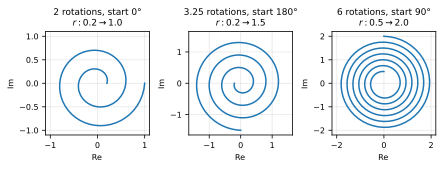

In [12]:
unit07.exercise_spiral()

The functions in `libpcp` provide sample solutions rather than the only possible solutions. Exercises can often be solved correctly in several ways, so we recommend developing and testing your own implementation before comparing it with the provided result.

<a id="doc_functions"></a>

## Documentation and Code Inspection

The function `dir` reveals which names are available in a module, but a name alone does not explain how a function should be used. We may also need to know its purpose, the arguments it accepts, and the result it returns. This information is commonly recorded in a **docstring**, a string placed immediately below the function definition. As discussed in <a href="PCP_04_control.html">Unit 4</a>, the built-in function `help` displays a function's docstring. For example, we can inspect the documentation of `unit10.add` as follows:

In [13]:
help(unit10.add)

Help on function add in module libpcp.unit10:

add(a, b)
    Return the sum of two numbers.

    Args:
        a: First number.
        b: Second number.

    Returns:
        Sum of a and b.



The expression `add(a, b)` is the function **signature**. It consists of the function name and its parameters and shows how the function can be called. The remaining text comes from the function's docstring. Its first sentence summarizes the function's purpose, the `Args` section describes its arguments, and the `Returns` section describes its result. Python does not enforce a single docstring format, but general conventions are described in <a href="https://peps.python.org/pep-0257/">PEP 257</a>. The functions in `libpcp` follow the more detailed format of the <a href="https://google.github.io/styleguide/pyguide.html#38-comments-and-docstrings">Google Python Style Guide</a>, using sections such as `Args` and `Returns` when appropriate. A consistent structure makes documentation easier to read and understand.

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">
<p style="color:#E65100; margin:0;">
<strong>Note: Docstrings and Comments.</strong>
Docstrings and comments both explain code, but they serve different purposes. A <strong>docstring</strong> documents a module, package, or function and can be displayed using tools such as <code>help</code>. A <strong>comment</strong> begins with <code>#</code> and explains a particular part of the implementation to someone reading the source code. Comments are ignored when Python executes the program and are not displayed by <code>help</code>.
</p>
</div>

Together, the signature and docstring describe a function's **interface**: how the function is called, what it does, and what it returns. Its **implementation** is the source code that performs the computation. A clear interface allows us to use a function without understanding every detail of its implementation. It also allows developers to correct or improve the implementation without changing how the function is called. This separation between interface and implementation extends beyond individual functions to modules, packages, and complete software systems.

<a id="background_api"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Application Programming Interfaces
</h2>

<p style="color:#1B5E20;">
An <strong>application programming interface</strong>, commonly abbreviated as <strong>API</strong>, specifies how one piece of software can use another. For a Python library, the API includes the functions and other definitions that programs are intended to access, together with their expected inputs, outputs, and behavior. The <strong>API documentation</strong> explains these rules to programmers. For example, a programmer reads the NumPy documentation to learn how <code>np.mean(x)</code> is used and then writes a program that calls this function. The program uses the API, while the programmer uses the API documentation.
</p>

<p style="color:#1B5E20;">
An API separates the functionality intended for <strong>library users</strong> from the internal details maintained by <strong>library developers</strong>. Users rely on documented functions and their expected behavior, while developers may change the underlying implementation without requiring users to change their programs. In Python, names beginning with an underscore usually indicate internal definitions that are not intended to belong to the public API. Such definitions may change between versions, whereas documented API elements should remain stable whenever possible.
</p>

<p style="color:#1B5E20;">
Scientific libraries commonly provide an <strong>API reference</strong> in which users can look up the available modules, functions, parameters, and return values. For example, the <a href="https://matplotlib.org/stable/api/index.html">Matplotlib API</a> documents tools for visualization, the <a href="https://scikit-learn.org/stable/api/index.html">scikit-learn API</a> describes machine-learning models and methods, and the <a href="https://librosa.org/doc/latest/api/">librosa API</a> covers functions for audio and music processing. Such documentation is often created semi-automatically with tools such as <a href="https://www.sphinx-doc.org/">Sphinx</a>, which can extract signatures and docstrings from source code and combine them with explanatory text. As a concrete example from music processing, the <a href="https://groupmm.github.io/synctoolbox/build/html/index.html">Sync Toolbox documentation</a> illustrates how a Python package can be documented using Sphinx. Automatic generation helps keep documentation connected to the code, but its quality still depends on clear interfaces and informative docstrings written by the developers.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
APIs are not limited to Python libraries. Web services use them to exchange data, databases use them to receive queries, and operating systems use them to provide access to files, networks, and hardware. Even a short Python program may rely on several API layers: your code calls NumPy or Matplotlib, these libraries call lower-level software, and the operating system ultimately communicates with the computer. Each layer can be used without mastering every layer below it. APIs are what make this cooperation possible. Learning to read an API is therefore more than learning to use a particular library; it is learning how to connect your own code with the wider world of software. See the <a href="https://en.wikipedia.org/wiki/API">Wikipedia article on APIs</a> for a broader introduction.
</p>

</div>

A documented interface is usually sufficient for using a function. Examining its implementation, however, can help us understand an algorithm, verify its behavior, or adapt it to a new problem. When Python source code is available, the standard-library module `inspect` provides the function `getsource` for displaying it:

In [14]:
print(inspect.getsource(unit10.add))

def add(a, b):
    """Return the sum of two numbers.

    Args:
        a: First number.
        b: Second number.

    Returns:
        Sum of a and b.
    """
    return a + b



The output shows the two main parts of the function. The triple-quoted string immediately below the definition is its docstring and describes the interface. The statement `return a + b` forms the implementation that performs the calculation. The same inspection tools can be applied to supporting functions and sample solutions in `libpcp`. The function `inspect.getsource` requires accessible Python source code and may not work for functions implemented outside ordinary Python files, such as functions provided by compiled libraries. In such cases, `help` and the library's external documentation provide the relevant information.

The **exercises** in this final unit are more **exploratory** than those in the preceding units. They ask you to inspect existing software, reorganize code, and make your own design decisions. Since many different approaches and outcomes are possible, no sample solutions are provided. Instead, use the concepts and inspection tools introduced in this unit to evaluate whether your results are clear, functional, and reusable.

<a id="exercise_libpcp"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 1: Listing Exercise Functions in <code>libpcp</code></strong>

<p style="color:#006064;">
The package <code>libpcp</code> contains ten modules corresponding to the ten PCP units. Functions providing sample solutions have names beginning with <code>exercise_</code>. Import the modules <code>unit01</code> through <code>unit10</code> and use <code>dir</code> to find all exercise functions contained in them.
</p>

<ul style="color:#006064; margin-bottom:0;">
  <li>Create a list named <code>exercise_functions</code> containing the complete name of every exercise function as a string, for example <code>'libpcp.unit07.exercise_spiral'</code>.</li>
  <li>Print the list in a readable form and determine how many exercise functions belong to each unit. Which unit contains the most, and which units contain none?</li>
  <li>Compare the result with the exercises in the corresponding notebooks. Are the function names informative and used consistently?</li>
  <li>Explain how the shared prefix <code>exercise_</code> helps you find the sample-solution functions automatically.</li>
</ul>
</div>

<a id="exercise_module"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 2: From Nested Functions to a Reusable Module</strong>

<p style="color:#006064;">
The sample-solution function <code>unit07.exercise_spiral</code> defines two additional functions, <code>generate_spiral</code> and <code>plot_spiral</code>, inside its function body. These are called <strong>nested functions</strong>. Their names are local to <code>exercise_spiral</code>, so they do not belong to the namespace of <code>unit07</code> and cannot be accessed directly using <code>unit07.generate_spiral</code> or <code>unit07.plot_spiral</code>. Their definitions and docstrings can nevertheless be examined as part of the source code of the outer function.
</p>

<ul style="color:#006064; margin-bottom:0;">
  <li>Use <code>dir</code> to verify that <code>exercise_spiral</code> belongs to the namespace of <code>unit07</code>, whereas <code>generate_spiral</code> and <code>plot_spiral</code> do not.</li>
  <li>Use <code>inspect.getsource</code> to display the implementation of <code>unit07.exercise_spiral</code> and locate the definitions and docstrings of its two nested functions.</li>
  <li>Explain why nested functions are appropriate when they are needed only within one function. What limitation arises if another notebook also needs to generate or plot a spiral?</li>
  <li>Move both <code>generate_spiral</code> and <code>plot_spiral</code> into a separate module named <code>spiral_tools.py</code>, and provide informative docstrings for both functions. Import the module and use <code>help</code> to verify that the functions and their documentation are accessible.</li>
  <li>Use the imported functions to generate and plot a spiral with parameters not used in the original examples.</li>
  <li>Finally, discuss whether both functions should be part of the module's public interface or whether <code>plot_spiral</code> should be treated as an internal helper, for example by renaming it <code>_plot_spiral</code>.</li>
</ul>
</div>

<a id="exercise_package"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 3: Your First Scientific Python Package</strong>

<p style="color:#006064;">
Create a small Python package based on a topic from PCP that you found particularly interesting. Possible themes include complex-number visualizations, signal generation, sampling experiments, Fourier analysis, or sound synthesis. Your package should provide a small collection of related functions that could be useful in another notebook or project.
</p>

<ul style="color:#006064; margin-bottom:0;">
  <li>Choose a package name and organize the code into at least two modules with clearly different responsibilities, such as computation and visualization.</li>
  <li>Give the package and its functions informative docstrings. Define a simple public API by importing selected functions in <code>&#95;&#95;init&#95;&#95;.py</code>.</li>
  <li>Create a short demonstration notebook that imports only your package and uses it to produce an interesting result, such as a figure, a generated signal, or a sound example.</li>
  <li>Test the package with several inputs and check at least one expected property of the result.</li>
  <li>Use <code>dir</code> and <code>help</code> to inspect the package from the perspective of a new user. Is it clear which functions are available and how they should be used?</li>
  <li>Briefly explain your design choices: which definitions belong to the public API, which remain internal, and how the package could be extended in the future.</li>
</ul>
</div>

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>